# IMPORT DATA SET AND LIBRARIES

In [88]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [20]:
data = pd.read_csv('/Users/sahil_jangid/codes/machine learning/UCI_Breast Cancer Wisconsin_knn/data/breast-cancer-wisconsin.data.txt' , header=None)

In [21]:
data.shape

(699, 11)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       699 non-null    int64 
 1   1       699 non-null    int64 
 2   2       699 non-null    int64 
 3   3       699 non-null    int64 
 4   4       699 non-null    int64 
 5   5       699 non-null    int64 
 6   6       699 non-null    object
 7   7       699 non-null    int64 
 8   8       699 non-null    int64 
 9   9       699 non-null    int64 
 10  10      699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [23]:
data[6] = pd.to_numeric(data[6] , errors='coerce')

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       699 non-null    int64  
 1   1       699 non-null    int64  
 2   2       699 non-null    int64  
 3   3       699 non-null    int64  
 4   4       699 non-null    int64  
 5   5       699 non-null    int64  
 6   6       683 non-null    float64
 7   7       699 non-null    int64  
 8   8       699 non-null    int64  
 9   9       699 non-null    int64  
 10  10      699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


In [25]:
col_names = ['Id', 'Clump_thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 
             'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

data.columns= col_names

In [26]:
data.drop(columns='Id' ,axis=1 ,  inplace=True)

# DATA CLEANING

In [27]:
data.isnull().sum()

Clump_thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [31]:
data['Bare_Nuclei'].unique()

array([ 1., 10.,  2.,  4.,  3.,  9.,  7., nan,  5.,  8.,  6.])

In [68]:
#will use median to impute missing values as median is robust to outliers

data['Bare_Nuclei'].fillna(data['Bare_Nuclei'].median() , inplace=True)
data.isnull().sum()

Clump_thickness                0
Uniformity_Cell_Size           0
Uniformity_Cell_Shape          0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

# OUTLIER DETECTIONS

In [33]:
print(round(data.describe()))

# knn is roubust to outliers

       Clump_thickness  Uniformity_Cell_Size  Uniformity_Cell_Shape  \
count            699.0                 699.0                  699.0   
mean               4.0                   3.0                    3.0   
std                3.0                   3.0                    3.0   
min                1.0                   1.0                    1.0   
25%                2.0                   1.0                    1.0   
50%                4.0                   1.0                    1.0   
75%                6.0                   5.0                    5.0   
max               10.0                  10.0                   10.0   

       Marginal_Adhesion  Single_Epithelial_Cell_Size  Bare_Nuclei  \
count              699.0                        699.0        683.0   
mean                 3.0                          3.0          4.0   
std                  3.0                          2.0          4.0   
min                  1.0                          1.0          1.0   
25%       

# data visulization

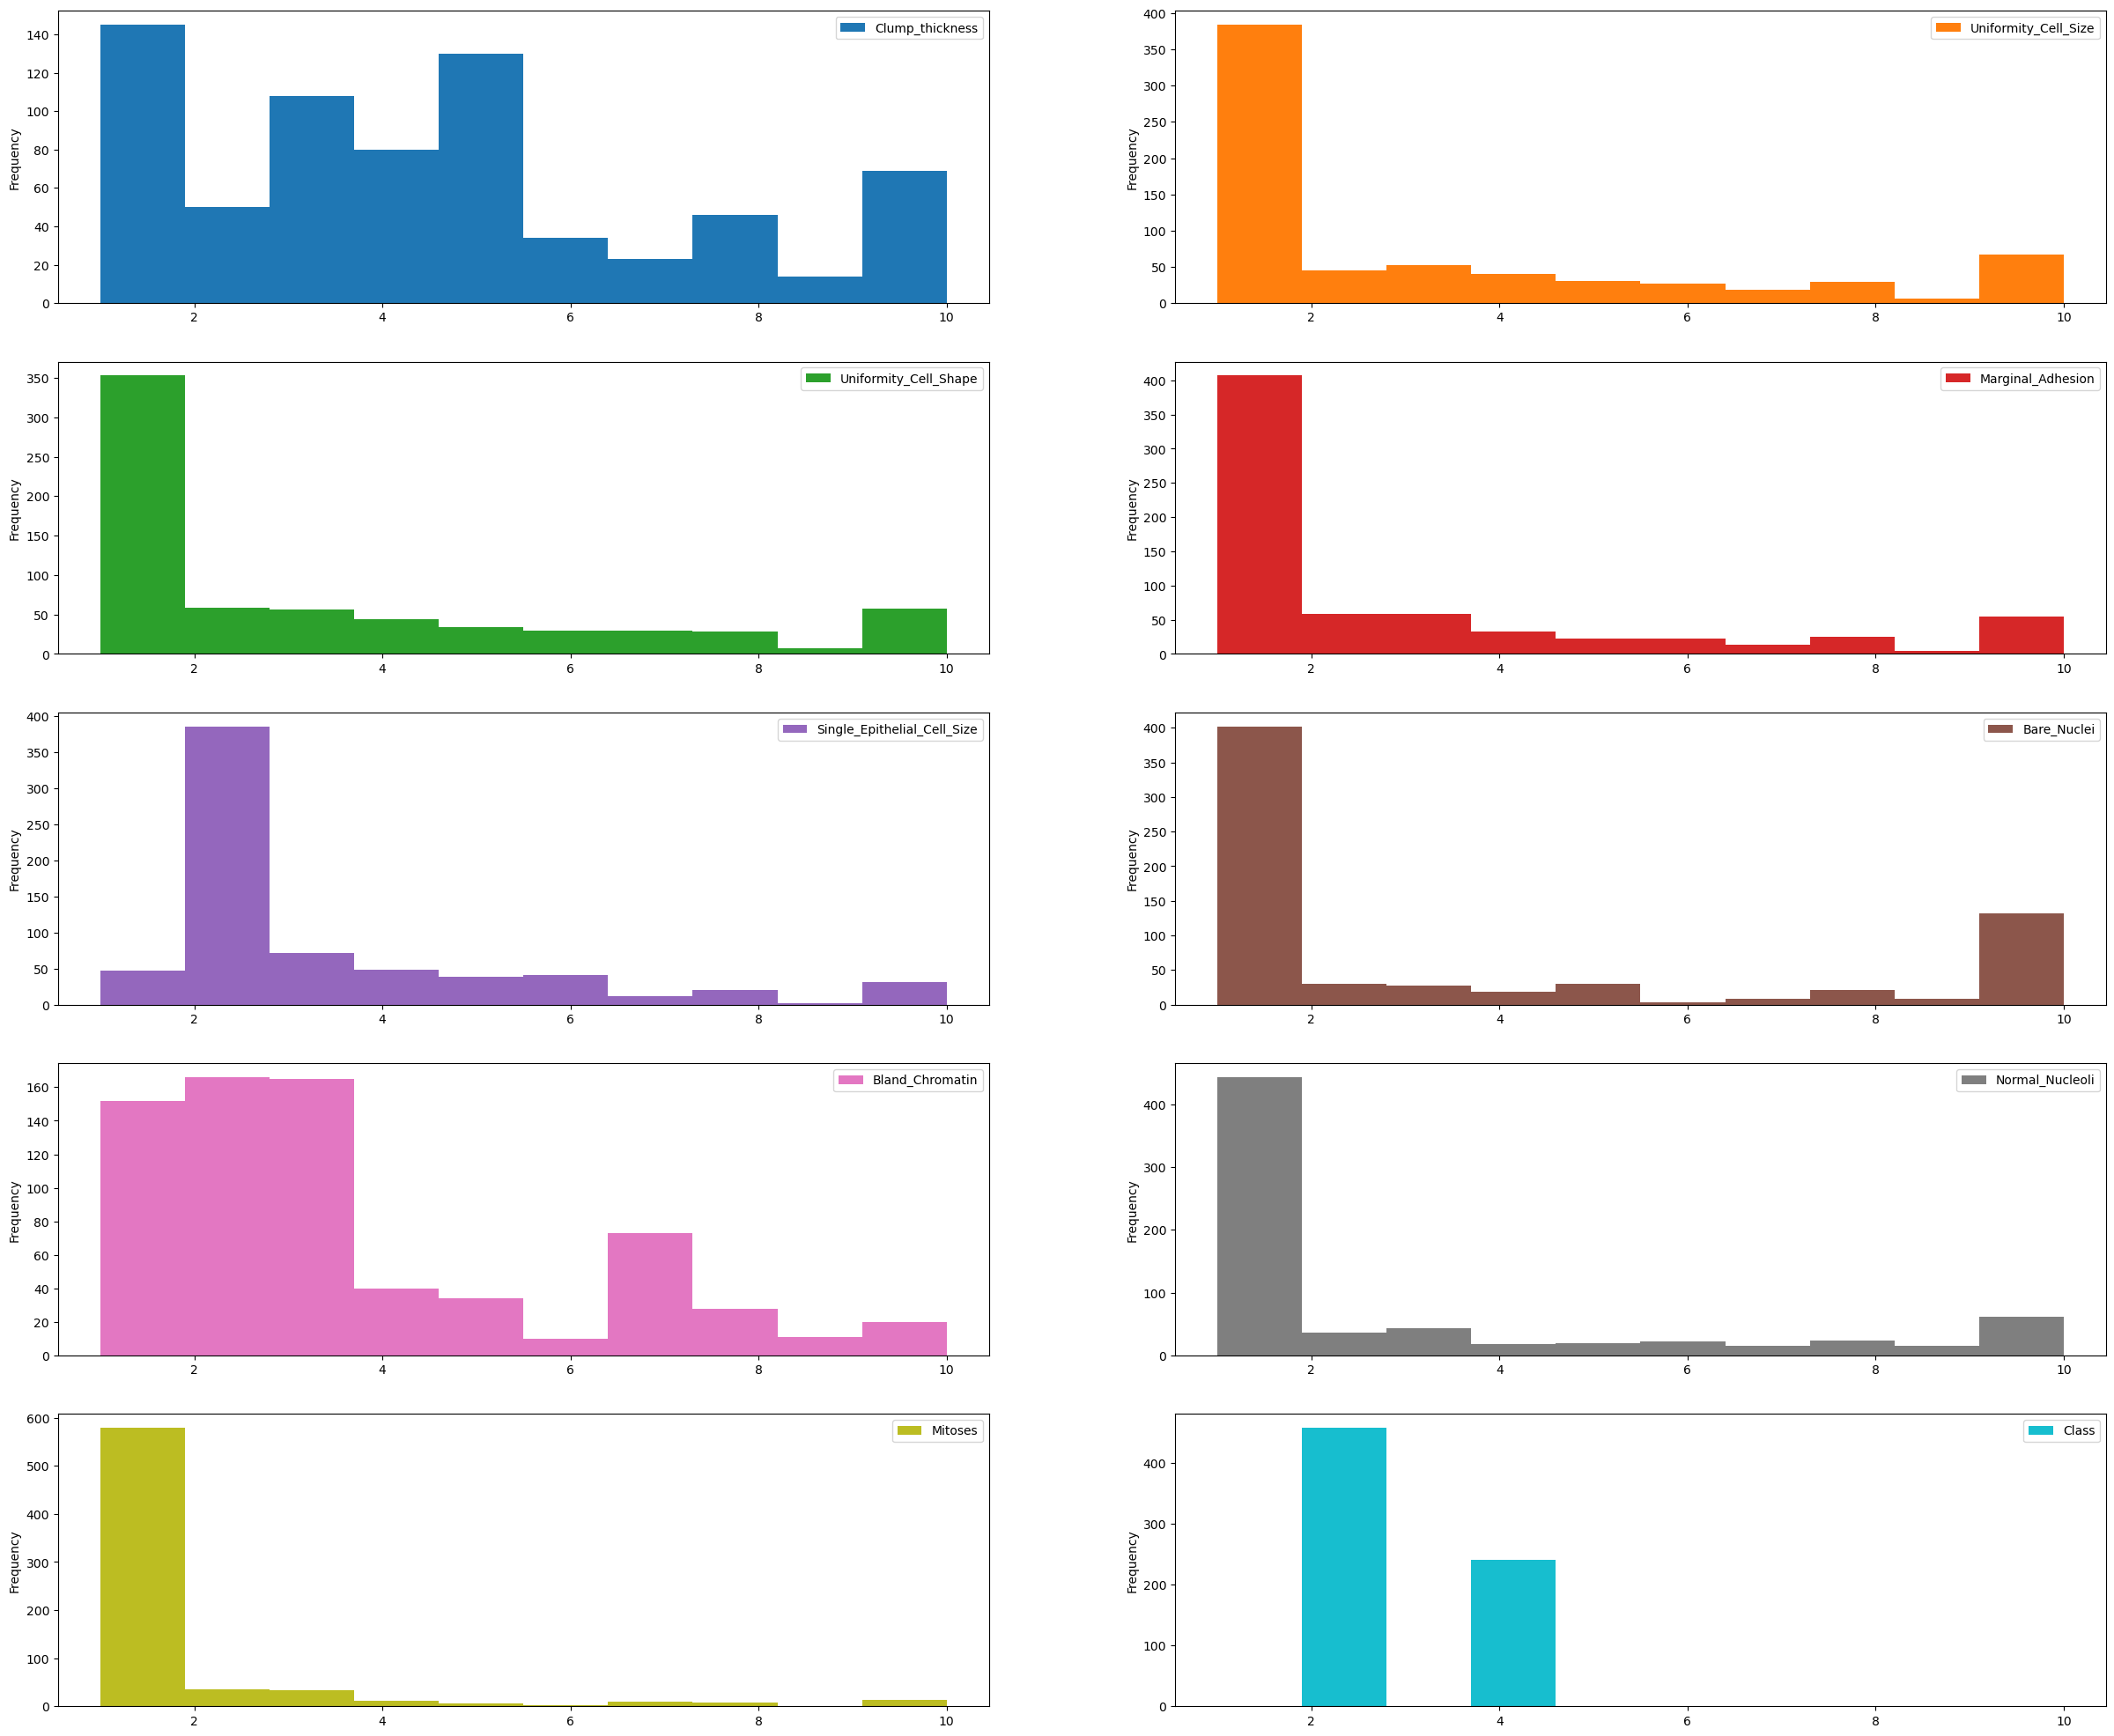

In [45]:
# plot histograms of the variables
plt.rcParams['figure.figsize']=(30,25)

data.plot(kind='hist' , sharex=False , sharey=False , subplots=True , layout=(5,2) )

plt.show()

In [47]:
# data is  positively skewed.

In [48]:
correlation = data.corr()

In [53]:
round(correlation['Class'].sort_values(ascending=False) , 4)

Class                          1.0000
Bare_Nuclei                    0.8227
Uniformity_Cell_Shape          0.8189
Uniformity_Cell_Size           0.8179
Bland_Chromatin                0.7566
Clump_thickness                0.7160
Normal_Nucleoli                0.7122
Marginal_Adhesion              0.6968
Single_Epithelial_Cell_Size    0.6828
Mitoses                        0.4232
Name: Class, dtype: float64

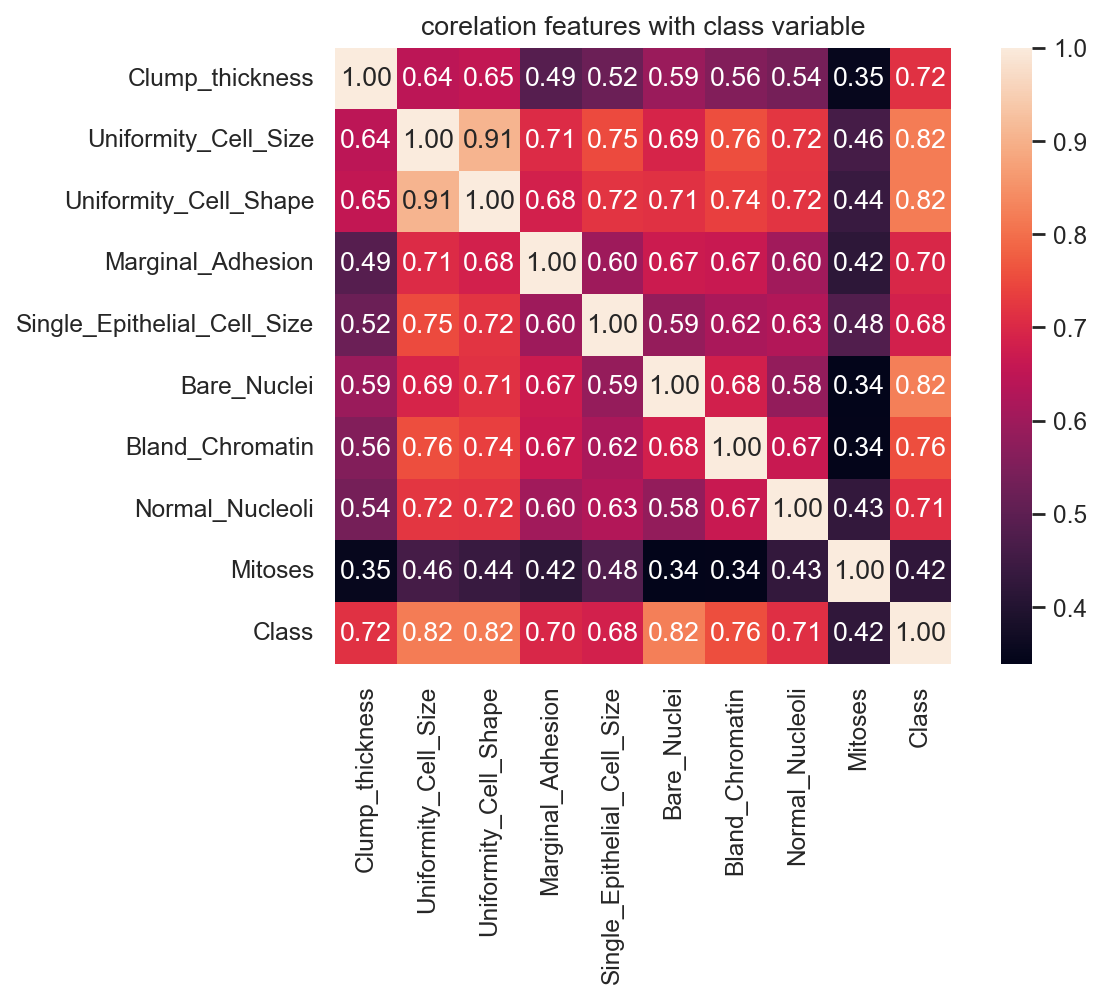

In [65]:
plt.figure(figsize=(8,5) ,dpi=160)
sns.set_theme(style='whitegrid')

plt.title('corelation features with class variable')
a = sns.heatmap(correlation , square=True , annot=True ,fmt ='.2f' , linecolor='red')
a.set_xticklabels(a.get_xticklabels() , rotation = 90)
a.set_yticklabels(a.get_yticklabels() , rotation = 0)

plt.show()

# data Spliting and scaling

In [73]:
x = data.drop(columns='Class')
y = data['Class']
x.shape ,y.shape

((699, 9), (699,))

In [74]:
x_train , x_test , y_train , y_test = train_test_split(x,y ,test_size=0.2)

In [75]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Model traning

In [84]:
model  = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train , y_train)

KNeighborsClassifier(n_neighbors=3)

# Evaluation 

In [ ]:
y_pred = model.predict(x_test)
print('accuracy_score : ',accuracy_score(y_test , y_pred))

accuracy_score :  0.95


In [87]:
#checking underfitting or overfitting
print('accuracy_score test data set: ',accuracy_score(y_test , y_pred))
print('accuracy_score train data set: ', model.score(x_train,y_train))

accuracy_score test data set:  0.95
accuracy_score train data set:  0.9767441860465116


# hyper parametr tunning to see if the accuracy increases

In [98]:
knn = KNeighborsClassifier(n_jobs=-1  )

pram_grid = {
    'n_neighbors' : list(range(1,21)),
    'weights' : ['uniform' , 'distance'],
    'metric' : ['euclidean', 'manhattan']
}

model2 = GridSearchCV(knn , pram_grid , cv=5)
model2.fit(x_train ,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_jobs=-1),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20],
                         'weights': ['uniform', 'distance']})

In [100]:
y_pred2 = model2.predict(x_test)

In [101]:
print('accuracy_score : ',accuracy_score(y_test , y_pred2))

accuracy_score :  0.9571428571428572


In [104]:
# same accuracy 
# we can use rfe to remove irrelevant columns and see if accuracy increase